In [1]:
from dask import delayed

@delayed
def inc(x):
    return x + 1

@delayed
def add(x, y):
    return x + y

In [4]:
x = inc(15)
y = inc(30)
total = add(x, y)

# Visualize DAG
total.visualize()

# Execute all tasks
total.compute()

47

In [5]:
from dask import delayed

def inc(x):
    return x + 1

def dec(x):
    return x - 1

def add(x, y):
    return x + y

In [6]:
# Dask Lazy evaluation
from dask.distributed import Client

c = Client(n_workers=4)

x = c.submit(inc, 1)
y = c.submit(dec, 2)
total = c.submit(add, x, y)

In [13]:
lsof -i :8787


SyntaxError: illegal target for annotation (801273610.py, line 1)

: 

In [10]:
total.compute()

AttributeError: 'Future' object has no attribute 'compute'

In [11]:
from dask.distributed import progress
progress(f)

NameError: name 'f' is not defined

In [1]:
from dask.distributed import Client
import dask.bag as db

# Create Dask client
client = Client(n_workers=4) #dashboard_port=38305)

# Create list of integers
integer_list = list(range(1, 1001))

# Partition list with Dask
dask_bag = db.from_sequence(integer_list, partition_size=100)

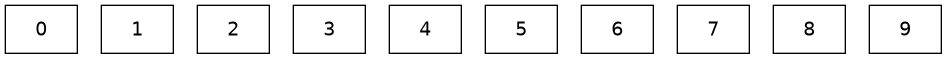

In [2]:
dask_bag.visualize()

In [3]:
# Compute square of integer list
squared_bag = dask_bag.map(lambda x: x ** 2)

# Compute and print the squared list
squared_list = squared_bag.compute()
print(squared_list)

[1, 4, 9, 16, 25, 36, 49, 64, 81, 100, 121, 144, 169, 196, 225, 256, 289, 324, 361, 400, 441, 484, 529, 576, 625, 676, 729, 784, 841, 900, 961, 1024, 1089, 1156, 1225, 1296, 1369, 1444, 1521, 1600, 1681, 1764, 1849, 1936, 2025, 2116, 2209, 2304, 2401, 2500, 2601, 2704, 2809, 2916, 3025, 3136, 3249, 3364, 3481, 3600, 3721, 3844, 3969, 4096, 4225, 4356, 4489, 4624, 4761, 4900, 5041, 5184, 5329, 5476, 5625, 5776, 5929, 6084, 6241, 6400, 6561, 6724, 6889, 7056, 7225, 7396, 7569, 7744, 7921, 8100, 8281, 8464, 8649, 8836, 9025, 9216, 9409, 9604, 9801, 10000, 10201, 10404, 10609, 10816, 11025, 11236, 11449, 11664, 11881, 12100, 12321, 12544, 12769, 12996, 13225, 13456, 13689, 13924, 14161, 14400, 14641, 14884, 15129, 15376, 15625, 15876, 16129, 16384, 16641, 16900, 17161, 17424, 17689, 17956, 18225, 18496, 18769, 19044, 19321, 19600, 19881, 20164, 20449, 20736, 21025, 21316, 21609, 21904, 22201, 22500, 22801, 23104, 23409, 23716, 24025, 24336, 24649, 24964, 25281, 25600, 25921, 26244, 26569, 

In [4]:
import dask.array as da
import numpy as np

# Number of points to use for the Monte Carlo simulation
n_points = 10**7

# Create Dask array of random points
x = da.random.random(n_points, chunks=100000)
y = da.random.random(n_points, chunks=100000)

# Compute distance from (0, 0)
dist = x**2 + y**2

# Count points inside the unit circle
inside_circle = (dist <= 1).sum()


# Approximate π
pi_approx = (4 * inside_circle / n_points).compute()
print("Approximate value of π:", pi_approx)

Approximate value of π: 3.1412476


In [5]:
import dask.array as da

# Number of points to use for the Monte Carlo simulation
n_points = 10**7

# Create Dask array of random points
points = da.random.random((n_points, 2), chunks=(100000, 2))

# Compute distance from (0, 0)
dist = (points ** 2).sum(axis=1)

# Count points inside the unit circle
inside_circle = (dist <= 1).sum()

# Approximate π
pi_approx = (4 * inside_circle / n_points).compute()
print("Approximate value of π:", pi_approx)

Approximate value of π: 3.1411012
